In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
import time 
import requests
from tqdm import tqdm
from dotenv import load_dotenv
load_dotenv

<function dotenv.main.load_dotenv(dotenv_path: str | ForwardRef('os.PathLike[str]') | None = None, stream: IO[str] | None = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: str | None = 'utf-8') -> bool>

In [ ]:
# use only entries post 2010 JAN 01

df = pd.read_csv("data/complete.csv", usecols=range(0, 11))
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 88875 entries, 0 to 88874
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              88875 non-null  str    
 1   city                  88679 non-null  str    
 2   state                 81356 non-null  str    
 3   country               76314 non-null  str    
 4   shape                 85757 non-null  str    
 5   duration (seconds)    88873 non-null  object 
 6   duration (hours/min)  85772 non-null  str    
 7   comments              88749 non-null  str    
 8   date posted           88875 non-null  str    
 9   latitude              88875 non-null  str    
 10  longitude             88875 non-null  float64
dtypes: float64(1), object(1), str(9)
memory usage: 7.5+ MB


C:\Users\wslid\AppData\Local\Temp\ipykernel_29296\586527434.py:3: DtypeWarning: Columns (0: duration (seconds)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("complete.csv", usecols=range(0, 11))


In [156]:
# convert datetime to datetime datatype

df['datetime'] = pd.to_datetime(df['datetime'].astype(str), errors='coerce')

print("Datetime conversion summary:")
print(df['datetime'].describe())
print(f"\nMissing datetimes: {df['datetime'].isna().sum():,}")

# Drop rows that couldn't be parsed 
df = df.dropna(subset=['datetime']).copy()

# post-2010 sightings dataframe to insert weather data into
# Fix: Use a string or proper datetime for comparison
sighting_wx_df = df[df['datetime'] >= '2010-01-01'].copy()
sighting_wx_df['rounded_dt'] = sighting_wx_df['datetime'].dt.round('h')
sighting_wx_df['date_str'] = sighting_wx_df['rounded_dt'].dt.strftime('%Y-%m-%d')
sighting_wx_df['hour_str'] = sighting_wx_df['rounded_dt'].dt.strftime('%H') 

sighting_wx_df.head()



Datetime conversion summary:
count                         87613
mean     2004-04-04 08:00:34.616096
min             1906-11-11 00:00:00
25%             2001-06-25 21:00:00
50%             2006-10-03 23:45:00
75%             2011-05-22 19:31:00
max             2014-05-08 18:45:00
Name: datetime, dtype: object

Missing datetimes: 1,262


,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude,rounded_dt,date_str,hour_str
230,2010-10-10 01:00:00,orchard park,ny,us,light,7200,a few hours,Xmas colored rotating lights. ((NUFORC Note: ...,1/5/2011,42.7675000,-78.744167,2010-10-10 01:00:00,2010-10-10,01
231,2010-10-10 02:30:00,harrisburg,pa,us,circle,240,4 minutes,possible UFO sighting,11/21/2010,40.2736111,-76.884722,2010-10-10 02:00:00,2010-10-10,02
232,2010-10-10 03:00:00,euclid,oh,us,circle,180,3 minutes,2 objects blinking red and white&#44 disappear...,11/21/2010,41.5930556,-81.526944,2010-10-10 03:00:00,2010-10-10,03
233,2010-10-10 08:30:00,starr,sc,us,formation,600,5-10 mins,Strange orange lights in the night sky,11/21/2010,34.3769444,-82.695833,2010-10-10 08:00:00,2010-10-10,08
234,2010-10-10 10:45:00,leominster,ma,us,flash,0,NaN,we were in the car and i looked out the window...,11/21/2010,42.5250000,-71.760278,2010-10-10 11:00:00,2010-10-10,11


In [162]:
wx_api_key = os.getenv("WX_API_KEY")

In [ ]:

wx_api_key = os.getenv("WX_API_KEY")


# Add the new columns first (with None values)
sighting_wx_df['weather_cloud'] = None
sighting_wx_df['weather_temp_f'] = None
sighting_wx_df['weather_condition'] = None

print(f"Starting weather fetch for {len(sighting_wx_df):,} sightings...")


for idx, row in tqdm(sighting_wx_df.iterrows(), total=len(sighting_wx_df)):
    try:
        lat = str(row['latitude']).strip()
        lon = str(row['longitude']).strip()
        date = str(row['date_str']).strip()
        hour = str(row['hour_str']).strip()
        
        baseurl = "http://api.weatherapi.com/v1/"
        historyurl = (
            f"{baseurl}history.json"
            f"?key={wx_api_key}"
            f"&q={lat},{lon}"          
            f"&dt={date}"
            f"&hour={hour}"            
        )
        
        response = requests.get(historyurl, timeout=15)
        response.raise_for_status()
        data = response.json()
        
        hour_data = data['forecast']['forecastday'][0]['hour'][0]
        
        # Update the dataframe row by row
        sighting_wx_df.at[idx, 'weather_cloud']     = hour_data.get('cloud')
        sighting_wx_df.at[idx, 'weather_temp_f']    = hour_data.get('temp_f')
        sighting_wx_df.at[idx, 'weather_condition'] = hour_data.get('condition', {}).get('text')
        
        #time.sleep(0.1)        
        
    except Exception:
        pass

    if (idx + 1) % 500 == 0:
        checkpoint_file = f"sightings_weather_checkpoint_{idx+1}.csv"
        sighting_wx_df.to_csv(checkpoint_file, index=False)
        print(f"\n Checkpoint saved at row {idx+1} → {checkpoint_file}")


print(sighting_wx_df.head(10))

# Save the result
sighting_wx_df.to_csv("sightings_with_weather.csv", index=False)

TypeError: str expected, not NoneType

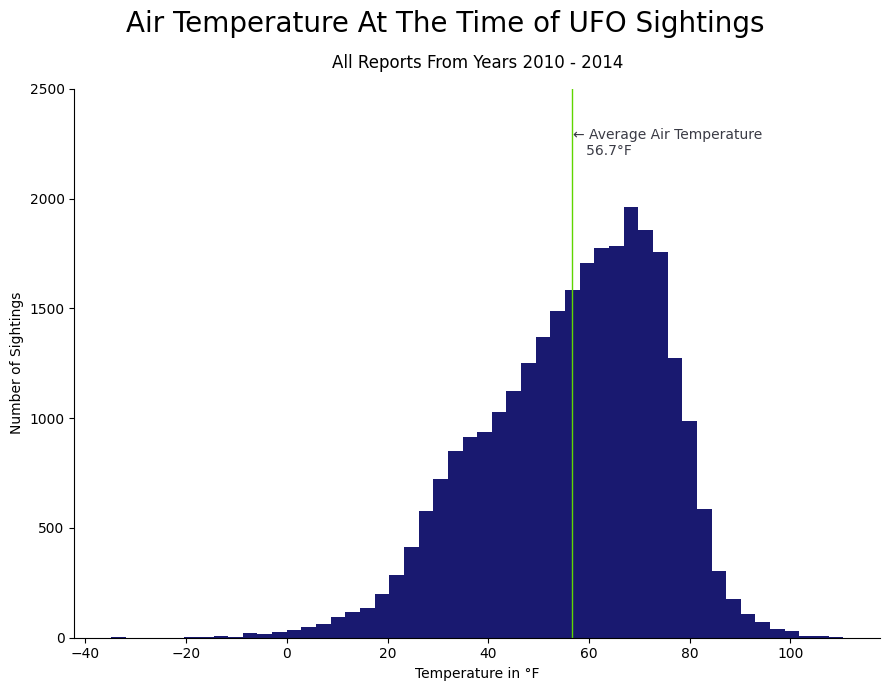

In [158]:
sighting_wx_conditions_df = pd.read_csv("sightings_with_weather.csv")
temperature = pd.to_numeric(sighting_wx_conditions_df['weather_temp_f'].astype(str).str.replace(r".*/.*", "", regex=True))
mean_temperature = temperature.mean().round(2)

plt.figure(figsize=(9,7))

plt.hist(temperature, bins=50, color="midnightblue")

plt.xlabel("Temperature in °F")
plt.ylabel("Number of Sightings")
plt.suptitle("Air Temperature At The Time of UFO Sightings", fontsize=20)
plt.title("All Reports From Years 2010 - 2014", fontsize=12, pad=15)

plt.ylim(0, 2500)

ax = plt.gca()
ax.axvline(mean_temperature, linewidth=1, color="#60D600")
ax.text(mean_temperature + 0.2, 2200,
        f"← Average Air Temperature\n   {mean_temperature}°F",
        color="#3a3b45")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

In [ ]:
print(sighting_wx_conditions_df['weather_condition'].unique())

<StringArray>
[                         'Clear',                          'Sunny',
                  'Partly cloudy',                         'Cloudy',
           'Patchy rain possible',         'Moderate rain at times',
                       'Overcast',  'Moderate or heavy rain shower',
            'Heavy rain at times',                              nan,
            'Light freezing rain', 'Moderate or heavy snow showers',
                  'Moderate snow',           'Patchy moderate snow']
Length: 14, dtype: str


In [ ]:
clear_df = sighting_wx_df[sighting_wx_df['weather_condition'] == 'Clear'].copy()

clear_df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude,rounded_dt,date_str,hour_str,weather_cloud,weather_temp_f,weather_condition
230,2010-10-10 01:00:00,orchard park,ny,us,light,7200,a few hours,Xmas colored rotating lights. ((NUFORC Note: ...,1/5/2011,42.7675000,-78.744167,2010-10-10 01:00:00,2010-10-10,01,8,43.3,Clear
231,2010-10-10 02:30:00,harrisburg,pa,us,circle,240,4 minutes,possible UFO sighting,11/21/2010,40.2736111,-76.884722,2010-10-10 02:00:00,2010-10-10,02,0,48.5,Clear
232,2010-10-10 03:00:00,euclid,oh,us,circle,180,3 minutes,2 objects blinking red and white&#44 disappear...,11/21/2010,41.5930556,-81.526944,2010-10-10 03:00:00,2010-10-10,03,8,52.2,Clear
241,2010-10-10 20:00:00,san angelo,tx,us,oval,60,1 minute,I was coming back from the grocery store aroun...,11/21/2010,31.4636111,-100.436667,2010-10-10 20:00:00,2010-10-10,20,5,76.1,Clear
242,2010-10-10 20:20:00,windsor,ct,us,fireball,5,5 seconds,Bus sized fireball object over 91 about 3-400 ...,5/2/2014,41.8525000,-72.644167,2010-10-10 20:00:00,2010-10-10,20,3,50.8,Clear


condition_groups
Clear     18869
Cloudy     7272
Rain       1553
Other       255
Snow         73
Name: count, dtype: int64


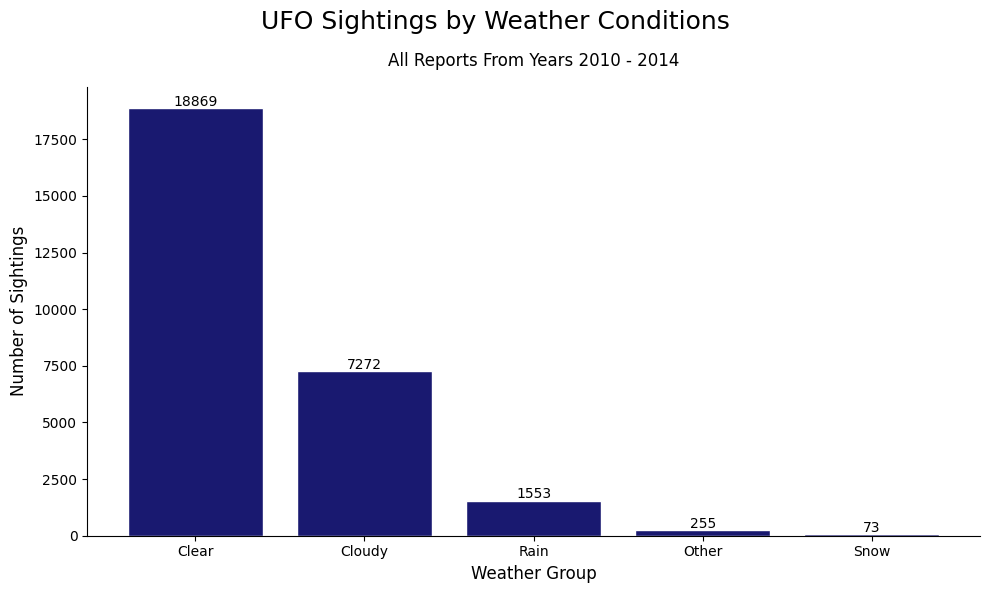

In [ ]:
condition_groups = {
    'Clear': 'Clear', 
    'Sunny': 'Clear',
    'Partly cloudy': 'Cloudy', 
    'Overcast': 'Cloudy', 
    'Cloudy': 'Cloudy',
    'Patchy rain possible': 'Rain', 
    'Moderate rain at times': 'Rain', 
    'Moderate or heavy rain shower': 'Rain', 
    'Heavy rain at times': 'Rain', 
    'Light freezing rain': 'Rain',
    'Moderate or heavy snow showers': 'Snow', 
    'Moderate snow': 'Snow', 
    'Patchy moderate snow': 'Snow',
}

sighting_wx_conditions_df['condition_groups'] = (
    sighting_wx_conditions_df['weather_condition']
    .fillna('Unknown')
    .map(condition_groups)
    .fillna('Other')       
)

# 3. Show the counts
print(sighting_wx_conditions_df['condition_groups'].value_counts())

# 4. Plot it correctly
counts = sighting_wx_conditions_df['condition_groups'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color='midnightblue', edgecolor='white')

plt.suptitle("UFO Sightings by Weather Conditions", fontsize=18)
plt.title("All Reports From Years 2010 - 2014", fontsize=12, pad=15)
plt.xlabel("Weather Group", fontsize=12)
plt.ylabel("Number of Sightings", fontsize=12)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels on top of bars
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
sighting_wx_conditions_df['condition_groups'] = (
    sighting_wx_conditions_df['weather_condition']
    .fillna('Unknown')
    .map(condition_groups)
    .fillna('Other')       
)

sighting_wx_conditions_df.to_csv('data/sighting_with_weather_v2.csv')